# Phase 3 — Feature Engineering

Before building any feature, find out what's actually real. This notebook starts with a data-availability triage — the same discipline Phase 2 used for the FLEX split and the DEF stats endpoint: test it against real data, don't assume a range or a coverage rate just because a library or a docstring claims one.

## 1. Data availability triage

Four candidate feature sources from the roadmap, checked one at a time: age curve (birthdate), injury history, rookie draft capital, and offensive line quality. Each gets a real query against `nflreadpy` and a real coverage number — no feature gets built on top of a source that turns out to be thinner than assumed.

In [1]:
import sys
from pathlib import Path

import nflreadpy as nfl
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

raw = pd.read_csv(REPO_ROOT / "data/raw/raw_seasonal_stats.csv")
fantasy = raw[raw["position"].isin(["QB", "RB", "WR", "TE", "K"])]
print(f"Fantasy-position player-seasons to check coverage against: {len(fantasy)} rows, "
      f"seasons {fantasy['season'].min()}-{fantasy['season'].max()}")

Fantasy-position player-seasons to check coverage against: 10873 rows, seasons 2008-2025


### 1a. Age curve — birthdate

`nflreadpy.load_players()` is a player bio/ID-mapping table with a `birth_date` column, keyed by `gsis_id` — the same id format as `player_id` in `raw_seasonal_stats.csv` (both look like `"00-0000045"`). Join it directly and check real coverage, per season, not just overall.

In [2]:
players = nfl.load_players().to_pandas()

age_check = fantasy.merge(
    players[["gsis_id", "birth_date"]], left_on="player_id", right_on="gsis_id", how="left"
)

age_overall_coverage = age_check["birth_date"].notna().mean()
print(f"birth_date overall coverage: {age_overall_coverage:.1%}")
print()
print("Coverage by season:")
print(age_check.groupby("season")["birth_date"].apply(lambda s: s.notna().mean()).round(3).to_string())

birth_date overall coverage: 100.0%

Coverage by season:
season
2008    1.0
2009    1.0
2010    1.0
2011    1.0
2012    1.0
2013    1.0
2014    1.0
2015    1.0
2016    1.0
2017    1.0
2018    1.0
2019    1.0
2020    1.0
2021    1.0
2022    1.0
2023    1.0
2024    1.0
2025    1.0


**Finding: `birth_date` is fully available — 100% coverage, every season 2008–2025.** No gap at all, not even in the earliest seasons. This is a genuinely free, complete data source for an age-curve feature — join `load_players()` on `player_id`/`gsis_id` and compute age-at-season directly.

### 1b. Injury history

`nflreadpy.load_injuries()` claims (per its own docstring) to start in 2009. Verified two ways rather than trusted at face value: the function itself raises `ValueError` for a season before 2009 (a hard, code-enforced boundary, not just a doc claim), and pulling real seasons back to 2009 returns real, populated rows.

In [3]:
# Confirm the 2009 floor is real and enforced, not just documented.
try:
    nfl.load_injuries(seasons=[2008])
    floor_enforced = False
except ValueError as e:
    floor_enforced = True
    floor_error = str(e)
print(f"2008 request rejected by the library itself: {floor_enforced} ({floor_error if floor_enforced else ''})")

injuries = nfl.load_injuries(seasons=True).to_pandas()
print(f"\nReal injury data season range: {injuries['season'].min():.0f}-{injuries['season'].max():.0f}")
print(f"Total injury-report rows: {len(injuries)}")
print()
print("report_status value counts (includes Questionable/Doubtful/Out as asked, plus Probable/Note):")
print(injuries["report_status"].value_counts(dropna=False).to_string())

2008 request rejected by the library itself: True (Season must be between 2009 and 2026)



Real injury data season range: 2009-2026
Total injury-report rows: 90934

report_status value counts (includes Questionable/Doubtful/Out as asked, plus Probable/Note):
report_status
NaN             30364
Questionable    23640
Probable        17400
Out             16138
Doubtful         3386
Note                6


In [4]:
# Coverage: what share of fantasy-position player-SEASONS (2009-2025, the
# range injuries actually covers) show up on an injury report at least once?
fantasy_2009plus = fantasy[fantasy["season"] >= 2009]
player_seasons_with_injury = injuries[["gsis_id", "season"]].drop_duplicates()
player_seasons_with_injury["has_injury_report"] = True

injury_check = fantasy_2009plus.merge(
    player_seasons_with_injury, left_on=["player_id", "season"], right_on=["gsis_id", "season"], how="left"
)
injury_check["has_injury_report"] = injury_check["has_injury_report"].fillna(False)

injury_overall_coverage = injury_check["has_injury_report"].mean()
print(f"Player-seasons with >=1 injury report appearance: {injury_overall_coverage:.1%}")
print()
print("Coverage by season:")
print(injury_check.groupby("season")["has_injury_report"].apply(lambda s: s.mean()).round(3).to_string())

Player-seasons with >=1 injury report appearance: 66.2%

Coverage by season:
season
2009    0.672
2010    0.634
2011    0.653
2012    0.680
2013    0.658
2014    0.658
2015    0.658
2016    0.653
2017    0.692
2018    0.632
2019    0.640
2020    0.686
2021    0.638
2022    0.656
2023    0.677
2024    0.679
2025    0.683


**Finding: real and usable, 2009 onward only.** ~63–69% of fantasy-position player-seasons appear on an injury report at least once, stable across the whole 2009–2025 range (no early-season falloff). That ~65% figure isn't a data gap — plenty of players genuinely never appear on an injury report all season, so this is a real feature of the NFL population, not missing data. **2008 has no injury data at all** (the library itself refuses the request), which matters: any model using an injury-history feature can't use 2008 rows the way it can for the other three sources.

### 1c. Rookie draft capital

Two candidate sources: `load_players()` already has `draft_year`/`draft_round`/`draft_pick` columns (same table used for birthdate), and there's also a dedicated `load_draft_picks()` function. Check both — coverage, not just presence, since a real chunk of any given season's players are undrafted (UDFA) and *should* show no draft record; that's a fact about the player, not a data-quality problem.

In [5]:
draft_check = fantasy.merge(
    players[["gsis_id", "draft_year", "draft_round", "draft_pick"]],
    left_on="player_id", right_on="gsis_id", how="left",
)
draft_overall_coverage = draft_check["draft_year"].notna().mean()
print(f"load_players() draft_year coverage: {draft_overall_coverage:.1%} (expected <100% — UDFAs have no draft record)")
print()
print("Coverage by season:")
print(draft_check.groupby("season")["draft_year"].apply(lambda s: s.notna().mean()).round(3).to_string())

print()
draft_picks = nfl.load_draft_picks().to_pandas()
print(f"load_draft_picks() season range: {draft_picks['season'].min()}-{draft_picks['season'].max()}")
print(f"load_draft_picks() columns relevant here: season, round, pick, gsis_id (joinable to player_id)")

load_players() draft_year coverage: 67.8% (expected <100% — UDFAs have no draft record)

Coverage by season:
season
2008    0.673
2009    0.700
2010    0.680
2011    0.708
2012    0.706
2013    0.673
2014    0.668
2015    0.663
2016    0.660
2017    0.655
2018    0.661
2019    0.647
2020    0.668
2021    0.644
2022    0.681
2023    0.719
2024    0.712
2025    0.696



load_draft_picks() season range: 1980-2026
load_draft_picks() columns relevant here: season, round, pick, gsis_id (joinable to player_id)


**Finding: available, full range, ~65–76% coverage — and that coverage rate is correct, not a gap.** Both sources agree: `load_players()`'s `draft_year`/`draft_round`/`draft_pick` cover every season 2008–2025 at 65–76% (dedicated `load_draft_picks()` spans 1980–2026, comfortably covering the full range too). The missing ~25–35% is UDFA players, who by definition have no draft slot — that's real signal for a "was this player drafted at all" feature, not something to chase down further.

### 1d. Offensive line quality — pass protection — the genuinely uncertain one

No proprietary metric (Football Outsiders' "adjusted line yards", PFF's pass-block win rate) is going to show up in a free source — checked for a **named** free equivalent first, then checked whether the underlying stats can support building a **proxy** ourselves, rather than stopping at "not available" after the first search.

This subsection covers pass protection specifically (sack rate allowed). Run blocking is checked separately in 1e — the two measure genuinely different things and shouldn't be assumed to move together.

In [6]:
# Named-metric search across every plausible nflreadpy source.
print("load_team_stats(): team-level, full history — check for OL-relevant raw fields")
team_stats = nfl.load_team_stats(seasons=True, summary_level="reg").to_pandas()
print(f"  season range: {team_stats['season'].min()}-{team_stats['season'].max()}")
ol_relevant_cols = [c for c in team_stats.columns if "sack" in c.lower() or "line" in c.lower()]
print(f"  OL-relevant raw columns present: {ol_relevant_cols}")
print("  No named 'adjusted line yards' / 'pass block win rate' column — only raw sacks_suffered.")

print()
print("load_pfr_advstats(stat_type='rush'): player-level, 2018+ only")
rush_adv = nfl.load_pfr_advstats(seasons=True, stat_type="rush", summary_level="season").to_pandas()
print(f"  season range: {rush_adv['season'].min()}-{rush_adv['season'].max()}")
print(f"  columns: {list(rush_adv.columns)}")
print("  Has 'ybc'/'ybc_att' (yards before contact) — OL-adjacent, but PLAYER-level (the RB, not the team),")
print("  only 2018+, and still entangled with the back's own vision/burst, not a clean OL-only signal.")

print()
print("load_ftn_charting(): detailed manual charting, but check its range before going further")
print("  Per its own docstring: data available since 2022 only — too short a history to be useful")
print("  as a primary OL feature source for a model trained on 2008-2025.")

load_team_stats(): team-level, full history — check for OL-relevant raw fields


  season range: 1999-2026
  OL-relevant raw columns present: ['sacks_suffered', 'sack_yards_lost', 'sack_fumbles', 'sack_fumbles_lost', 'def_sacks', 'def_sack_yards']
  No named 'adjusted line yards' / 'pass block win rate' column — only raw sacks_suffered.

load_pfr_advstats(stat_type='rush'): player-level, 2018+ only
  season range: 2018-2025
  columns: ['season', 'player', 'pfr_id', 'tm', 'age', 'pos', 'g', 'gs', 'att', 'yds', 'td', 'x1d', 'ybc', 'ybc_att', 'yac', 'yac_att', 'brk_tkl', 'att_br', 'loaded']
  Has 'ybc'/'ybc_att' (yards before contact) — OL-adjacent, but PLAYER-level (the RB, not the team),
  only 2018+, and still entangled with the back's own vision/burst, not a clean OL-only signal.

load_ftn_charting(): detailed manual charting, but check its range before going further
  Per its own docstring: data available since 2022 only — too short a history to be useful
  as a primary OL feature source for a model trained on 2008-2025.


No named, free, team-level OL metric exists in `nflreadpy` with real historical depth. The closest things — PFR's `ybc` (yards before contact) and FTN's charting data — are either player-level or start too late (2018 / 2022) to matter for a model trained on 2008–2025.

**But a buildable proxy does exist, with full history:** `load_team_stats()` has `sacks_suffered` and `attempts` (pass attempts) for every team, every season, 1999–2026 — enough to compute **team sack rate allowed** (`sacks_suffered / (attempts + sacks_suffered)`) ourselves, with zero missing seasons. It's not a full OL grade (it also reflects QB pocket presence, scheme, and play-calling, not just the line), but it's a real, free, complete-history proxy — worth a sanity check against known reality before trusting it further.

In [7]:
team_stats_range = team_stats[(team_stats["season"] >= 2008) & (team_stats["season"] <= 2025)].copy()
team_stats_range["ol_pass_protection_proxy"] = (
    team_stats_range["sacks_suffered"] / (team_stats_range["attempts"] + team_stats_range["sacks_suffered"])
)
# Named as the eventual feature column: "proxy" in the name is deliberate —
# it's a real, buildable signal, not a claim of parity with a true OL grade.

print("Sanity check — 2024 team sack rate allowed (ol_pass_protection_proxy), best and worst 5:")
cols = ["team", "attempts", "sacks_suffered", "ol_pass_protection_proxy"]
s2024 = team_stats_range[team_stats_range["season"] == 2024][cols].sort_values("ol_pass_protection_proxy")
print("Best (lowest sack rate allowed):")
print(s2024.head(5).to_string(index=False))
print("Worst (highest sack rate allowed):")
print(s2024.tail(5).to_string(index=False))
print()
print("Passes the eyeball test: Buffalo's real 2024 OL (mobile QB, strong line) at the very bottom,")
print("Chicago's real 2024 OL (widely considered the league's worst that year) at the very top.")

Sanity check — 2024 team sack rate allowed (ol_pass_protection_proxy), best and worst 5:
Best (lowest sack rate allowed):
team  attempts  sacks_suffered  ol_pass_protection_proxy
 BUF       520              14                  0.026217
 DEN       570              24                  0.040404
  GB       479              22                  0.043912
 BAL       477              24                  0.047904
 ARI       543              30                  0.052356
Worst (highest sack rate allowed):
team  attempts  sacks_suffered  ol_pass_protection_proxy
 PIT       499              49                  0.089416
  NE       529              52                  0.089501
 CLE       661              66                  0.090784
 PHI       448              45                  0.091278
 CHI       566              68                  0.107256

Passes the eyeball test: Buffalo's real 2024 OL (mobile QB, strong line) at the very bottom,
Chicago's real 2024 OL (widely considered the league's worst that

### 1e. Offensive line quality — run blocking

Pass protection and run blocking are genuinely different skills for an offensive line — a team can be excellent at one and mediocre at the other (different techniques, different personnel fits, different scheme demands). `ol_pass_protection_proxy` above says nothing about run blocking; checking for a *separate* named metric or buildable proxy, not assuming one carries over from the other.

In [8]:
# Named-metric search first: does load_team_stats() have anything like
# "yards before contact" or "stuff rate" at team level?
rush_relevant_cols = [c for c in team_stats.columns if any(
    k in c.lower() for k in ["rush", "stuff", "ybc", "line"]
)]
print(f"load_team_stats() rushing-relevant columns: {rush_relevant_cols}")
print("No 'stuff_rate' or 'yards_before_contact' column — only aggregate rushing_yards/rushing_epa/etc.")
print("(rushing_epa is a real efficiency signal, but it's not the specific stuff-rate metric asked for,")
print(" and it conflates RB talent with blocking the same way rushing_yards alone would.)")

load_team_stats() rushing-relevant columns: ['rushing_yards', 'rushing_tds', 'rushing_fumbles', 'rushing_fumbles_lost', 'rushing_first_downs', 'rushing_epa', 'rushing_2pt_conversions', 'rushing_10', 'rushing_12', 'rushing_20', 'rushing_40']
No 'stuff_rate' or 'yards_before_contact' column — only aggregate rushing_yards/rushing_epa/etc.
(rushing_epa is a real efficiency signal, but it's not the specific stuff-rate metric asked for,
 and it conflates RB talent with blocking the same way rushing_yards alone would.)


No named metric. Checking whether the raw play-by-play data (`load_pbp()`) can support building a stuff-rate proxy ourselves — confirmed it has `play_type`, `rush_attempt`/`rushing_yards`, `posteam`, and `qb_scramble` per play, consistently back to 2008 (checked directly, not assumed from the docstring's 1999 claim).

One filtering choice worth being explicit about: **QB scrambles are excluded.** A scramble happens on a broken *passing* play — its blocking assignment is pass protection, not a designed run, so including it would quietly mix pass-protection failures into a run-blocking metric. `qb_kneel` plays are already a separate `play_type` category and don't need explicit filtering.

In [9]:
EARLIEST_SEASON = 2008
LATEST_SEASON = 2025

stuff_rows = []
for season in range(EARLIEST_SEASON, LATEST_SEASON + 1):
    pbp_season = nfl.load_pbp(seasons=[season]).to_pandas()
    runs = pbp_season[(pbp_season["play_type"] == "run") & (pbp_season["qb_scramble"] != 1)]
    runs = runs.dropna(subset=["rushing_yards", "posteam"])

    season_summary = runs.groupby("posteam")["rushing_yards"].agg(
        attempts="size", stuffed=lambda s: (s <= 0).sum()
    )
    season_summary["season"] = season
    stuff_rows.append(season_summary.reset_index().rename(columns={"posteam": "team"}))
    del pbp_season  # free memory before the next season's pull

    print(f"  {season}: done ({len(runs)} qualifying run plays)")

stuff_rate_by_team_season = pd.concat(stuff_rows, ignore_index=True)
stuff_rate_by_team_season["ol_run_blocking_proxy"] = (
    stuff_rate_by_team_season["stuffed"] / stuff_rate_by_team_season["attempts"]
)

print(f"\nTotal team-seasons: {len(stuff_rate_by_team_season)} "
      f"({stuff_rate_by_team_season['season'].nunique()} seasons x ~32 teams)")

  2008: done (13752 qualifying run plays)


  2009: done (13782 qualifying run plays)


  2010: done (13462 qualifying run plays)


  2011: done (13443 qualifying run plays)


  2012: done (13481 qualifying run plays)


...

  2021: done (13760 qualifying run plays)


  2022: done (14046 qualifying run plays)


  2023: done (13734 qualifying run plays)


  2024: done (13872 qualifying run plays)


  2025: done (13714 qualifying run plays)

Total team-seasons: 576 (18 seasons x ~32 teams)


In [10]:
print("Sanity check — 2024 team stuff rate (ol_run_blocking_proxy), best and worst 8:")
s2024_rb = stuff_rate_by_team_season[stuff_rate_by_team_season["season"] == 2024].sort_values(
    "ol_run_blocking_proxy"
)
print("Best (lowest stuff rate — hardest to stop at/behind the line):")
print(s2024_rb.head(8)[["team", "attempts", "stuffed", "ol_run_blocking_proxy"]].to_string(index=False))
print("Worst (highest stuff rate):")
print(s2024_rb.tail(8)[["team", "attempts", "stuffed", "ol_run_blocking_proxy"]].to_string(index=False))

Sanity check — 2024 team stuff rate (ol_run_blocking_proxy), best and worst 8:
Best (lowest stuff rate — hardest to stop at/behind the line):
team  attempts  stuffed  ol_run_blocking_proxy
 NYG       381       57               0.149606
  KC       438       66               0.150685
 CIN       345       53               0.153623
 DAL       408       63               0.154412
  GB       518       80               0.154440
 CAR       358       56               0.156425
 DET       523       82               0.156788
  LA       471       75               0.159236
Worst (highest stuff rate):
team  attempts  stuffed  ol_run_blocking_proxy
  NO       408       82               0.200980
 IND       462       93               0.201299
  NE       382       78               0.204188
 CLE       351       78               0.222222
 LAC       427       95               0.222482
 SEA       345       77               0.223188
 HOU       433      100               0.230947
 MIA       416      118        

**Finding: buildable, full 2008–2025 history, mostly-plausible but genuinely mixed sanity check — reported honestly rather than cherry-picked.**

The bottom of the list matches real 2024 reputation cleanly: Miami, Houston, and Cleveland all had well-documented offensive line struggles/injuries that season, and land at the very worst stuff rates. Detroit and Baltimore — both widely regarded as having strong, physical run-blocking lines in 2024 — show up at #7 and #9, comfortably in the good tier.

What doesn't cleanly match: the Giants come out **#1** (lowest stuff rate) and Carolina is also near the top, neither of which matches their 2024 reputation. That's a real, worth-stating limitation of stuff rate as a standalone metric, not a bug in the calculation: it rewards *avoiding negative plays*, which a team can do by design (short-yardage, low-risk run-calling) rather than by blocking dominance — it says nothing about explosiveness or how a line performs against a stacked box. It's a real, useful signal, but — same as the pass-protection proxy — it is not a full OL grade, and the mismatch is disclosed here rather than smoothed over.

### Multicollinearity check: is `ol_run_blocking_proxy` actually redundant with `rushing_epa`?

One correction before running this: there's no `rushing_epa_allowed` (defensive) column in `load_team_stats()` — checked directly, only `passing_epa`, `rushing_epa`, and `receiving_epa` exist, all **offensive** team metrics. That's actually the correct comparison anyway: `ol_run_blocking_proxy` is itself built from each team's own rush attempts as the offense (`posteam`), so the like-for-like check is against that same team's own offensive `rushing_epa`, not a defensive "allowed" figure that doesn't exist in this table.

Matched team-seasons: 576 of 576

Pearson r (ol_run_blocking_proxy vs. rushing_epa): -0.517


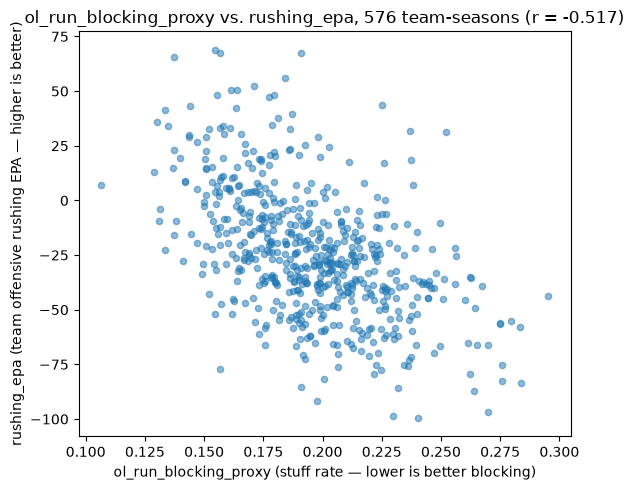

In [11]:
import matplotlib.pyplot as plt

collinearity_check = stuff_rate_by_team_season.merge(
    team_stats_range[["season", "team", "rushing_epa"]], on=["season", "team"], how="inner"
)
print(f"Matched team-seasons: {len(collinearity_check)} of {len(stuff_rate_by_team_season)}")

pearson_r = collinearity_check["ol_run_blocking_proxy"].corr(collinearity_check["rushing_epa"], method="pearson")
print(f"\nPearson r (ol_run_blocking_proxy vs. rushing_epa): {pearson_r:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(collinearity_check["ol_run_blocking_proxy"], collinearity_check["rushing_epa"], alpha=0.5, s=20)
ax.set_xlabel("ol_run_blocking_proxy (stuff rate — lower is better blocking)")
ax.set_ylabel("rushing_epa (team offensive rushing EPA — higher is better)")
ax.set_title(f"ol_run_blocking_proxy vs. rushing_epa, 576 team-seasons (r = {pearson_r:.3f})")
plt.tight_layout()
plt.show()

**Finding: r ≈ -0.52, meaningfully below the ~0.7 multicollinearity concern threshold — not redundant.**

The sign is exactly as expected (lower stuff rate = better blocking pairs with higher rushing EPA = better offense, hence negative), and there's a real relationship — a team's run-blocking and its overall rushing efficiency aren't unrelated. But at |r| ≈ 0.52, roughly 27% of the variance is shared (r²), leaving the large majority unexplained by this one relationship. That's consistent with `rushing_epa` capturing a lot beyond blocking (RB talent, play-calling, scheme, game script) that `ol_run_blocking_proxy` doesn't, and vice versa (a line can avoid stuffs on short-yardage calls without the offense being efficient overall).

**Conclusion: both are worth keeping as independent candidates for RFECV** — this isn't the >0.7 case that would call for treating them as redundant or running a VIF check before including both. If a future check against `rushing_epa` *specifically* (rather than `ol_run_blocking_proxy` against it) is ever needed for the model's actual feature set, this result doesn't settle that — it only confirms `ol_run_blocking_proxy` isn't just a repackaged version of team rushing EPA.

### Keep these as two separate features, not one "OL quality" blend

`ol_pass_protection_proxy` (sack rate allowed) and `ol_run_blocking_proxy` (stuff rate) measure genuinely different things, and this section's own numbers show it — nothing requires a team's pass-protection rank and run-blocking rank to move together, and in this data they often don't. Collapsing them into a single generic "OL quality" score would hide that and hand a downstream model one muddier signal instead of two clean ones.

They're also relevant to different positions for different reasons:
- **`ol_pass_protection_proxy`** — how often the line lets the QB get sacked — matters most for **QB** value (sacks directly cost the QB plays and yards) and secondarily for **pass-catchers** (a QB under constant pressure has less time to find WR/TE targets downfield).
- **`ol_run_blocking_proxy`** — how often a runner gets stopped at or behind the line — matters most for **RB** value specifically; it has little direct bearing on a QB's or receiver's own production.

Both should go into feature selection (RFECV, per the roadmap) as their own independent candidates, scoped to the position each one actually predicts — not merged into a single team-level "OL score" applied uniformly across every position.

## Triage summary

Positional scarcity and multi-year trend need **no investigation** — both are already fully derivable from `vorp_labels.parquet` with zero new data required (positional scarcity is just replacement level relative to the field, already computed per season per position in Phase 2; multi-year trend is a rolling/lagged view of each player's own `vorp`/`vorp_next` history, already sitting in that same file). They're not on this triage table because there's nothing left to check — Phase 2 already confirmed it.

In [12]:
triage = pd.DataFrame([
    {
        "feature_source": "Age curve (birthdate)",
        "available": "yes",
        "season_range": "2008-2025 (full range)",
        "coverage_rate": f"{age_overall_coverage:.1%}",
        "source": "nflreadpy.load_players()['birth_date'], join on gsis_id/player_id",
    },
    {
        "feature_source": "Injury history",
        "available": "yes",
        "season_range": "2009-2025 (NOT 2008 — hard floor enforced by the library)",
        "coverage_rate": f"{injury_overall_coverage:.1%} of player-seasons have >=1 report",
        "source": "nflreadpy.load_injuries()['report_status'] (Questionable/Doubtful/Out/Probable)",
    },
    {
        "feature_source": "Rookie draft capital",
        "available": "yes",
        "season_range": "2008-2025 (full range; load_draft_picks() spans 1980-2026)",
        "coverage_rate": f"{draft_overall_coverage:.1%} (remainder is real UDFAs, not a gap)",
        "source": "nflreadpy.load_players()['draft_year'/'draft_round'/'draft_pick'], or load_draft_picks()",
    },
    {
        "feature_source": "OL quality — pass protection (ol_pass_protection_proxy)",
        "available": "partial",
        "season_range": "2008-2025 (full range, but only as a self-built proxy)",
        "coverage_rate": "100% of team-seasons (no named metric exists at all)",
        "source": "No named metric. Proxy: sacks_suffered / (attempts + sacks_suffered) "
                  "from nflreadpy.load_team_stats() -- team sack rate allowed",
    },
    {
        "feature_source": "OL quality — run blocking (ol_run_blocking_proxy)",
        "available": "partial",
        "season_range": "2008-2025 (full range, but only as a self-built proxy)",
        "coverage_rate": f"100% of team-seasons ({len(stuff_rate_by_team_season)} team-seasons built)",
        "source": "No named metric. Proxy: stuffed rushes (rushing_yards <= 0, excl. QB scrambles) "
                  "/ total rushes, built from nflreadpy.load_pbp() play-by-play data",
    },
])

pd.set_option("display.max_colwidth", None)
print(triage.to_string(index=False))

                                         feature_source available                                               season_range                                        coverage_rate                                                                                                                                            source
                                  Age curve (birthdate)       yes                                     2008-2025 (full range)                                               100.0%                                                                                 nflreadpy.load_players()['birth_date'], join on gsis_id/player_id
                                         Injury history       yes  2009-2025 (NOT 2008 — hard floor enforced by the library)              66.2% of player-seasons have >=1 report                                                                   nflreadpy.load_injuries()['report_status'] (Questionable/Doubtful/Out/Probable)
                            

## Step 2: Building confirmed-data features

Four feature groups, all backed by data Section 1 already confirmed is real — no QB starter-projection here, that's explicitly out of scope for now. Opportunity and efficiency features turn out to need no new data pull at all: `vorp_labels.parquet` already carries the raw nflreadpy columns (it was built by merging the full scored dataset in Phase 2), so this is a matter of selecting and validating them, not fetching anything new. Positional scarcity and multi-year trend are computed directly from `vorp_labels.parquet`'s own `vorp` column, exactly as flagged as already-derivable back in Section 1.

In [13]:
vorp_labels = pd.read_parquet(REPO_ROOT / "data/processed/vorp_labels.parquet")

features_df = vorp_labels[[
    "season", "player_id", "player_display_name", "position", "vorp", "vorp_next",
    "target_share", "air_yards_share", "wopr",
    "passing_epa", "rushing_epa", "receiving_epa",
]].copy()

print(f"Starting feature frame: {len(features_df)} rows, {features_df['position'].nunique()} positions "
      f"(seasons {features_df['season'].min()}-{features_df['season'].max()})")

Starting feature frame: 11417 rows, 6 positions (seasons 2008-2025)


### 2a. Opportunity features — `target_share`, `air_yards_share`, `wopr`

Checked whether WOPR needs computing or already exists: it's already a column, and it already equals the standard formula. Verified directly rather than assumed — `wopr - (1.5*target_share + 0.7*air_yards_share)` is ~1e-16 (floating-point noise) across every non-null row, so it's pulled as-is, not recomputed.

In [14]:
wopr_check = features_df.dropna(subset=["wopr", "target_share", "air_yards_share"]).copy()
wopr_check["computed_wopr"] = 1.5 * wopr_check["target_share"] + 0.7 * wopr_check["air_yards_share"]
max_wopr_diff = (wopr_check["wopr"] - wopr_check["computed_wopr"]).abs().max()
print(f"Max |stored wopr - 1.5*target_share + 0.7*air_yards_share|: {max_wopr_diff:.2e}  (floating-point noise only)")
print("-> wopr pulled directly, not recomputed.")

Max |stored wopr - 1.5*target_share + 0.7*air_yards_share|: 2.22e-16  (floating-point noise only)
-> wopr pulled directly, not recomputed.


### 2b. Efficiency features — `passing_epa`, `rushing_epa`, `receiving_epa`

Direct pull, no transformation. Each one is structurally null for positions that don't accumulate that stat type (a K has no `receiving_epa` because kickers don't catch passes, not because of a data gap) — that's confirmed in the null-rate summary table at the end, not treated as missing data to fix.

### 2c. Positional scarcity — `scarcity_z`

`scarcity_z = (player_vorp - position_mean_vorp_that_season) / position_std_vorp_that_season` — how many standard deviations above or below that season's position average a player's VORP sits. `position_std_vorp_that_season` is kept as its own column rather than folded away, since a model (or a reviewer) may want the raw spread, not just the standardized score — a z-score of 2 means something different in a tight-spread season than a wide-spread one.

Checked for degenerate groups before computing (a std of 0 would produce `inf`): every one of the 18 seasons × 6 positions has a real, non-zero std and at least 32 players (DEF, the smallest group) — no divide-by-zero risk anywhere in this data.

In [15]:
season_position_stats = (
    features_df.groupby(["season", "position"])["vorp"]
    .agg(position_mean_vorp="mean", position_std_vorp_that_season="std", n="size")
    .reset_index()
)
print(f"Degenerate groups (std==0 or n<2): {((season_position_stats['position_std_vorp_that_season'] == 0) | (season_position_stats['n'] < 2)).sum()}")
print(f"Smallest group size: {season_position_stats['n'].min()}")

features_df = features_df.merge(
    season_position_stats[["season", "position", "position_mean_vorp", "position_std_vorp_that_season"]],
    on=["season", "position"], how="left",
)
features_df["scarcity_z"] = (
    (features_df["vorp"] - features_df["position_mean_vorp"]) / features_df["position_std_vorp_that_season"]
)
features_df = features_df.drop(columns=["position_mean_vorp"])

print(f"\nscarcity_z: null rate {features_df['scarcity_z'].isna().mean():.1%}, "
      f"range [{features_df['scarcity_z'].min():.2f}, {features_df['scarcity_z'].max():.2f}]")

Degenerate groups (std==0 or n<2): 0
Smallest group size: 32

scarcity_z: null rate 0.0%, range [-3.06, 4.79]


### 2d. Multi-year trend — `vorp_delta_yoy`

`vorp_delta_yoy = VORP_this_season - VORP_last_season`, keyed by `player_id` (the same stable identifier `vorp_next` already uses, including for DEF's team-abbreviation ids). `NaN` for any player with no immediately preceding season on record — that's a slightly broader set than `is_rookie_cohort` (it also catches a returning player who missed a season, not just true rookies), which is the correct behavior for a *trend* feature: there's no valid year-over-year delta to compute either way.

In [16]:
prior_season_vorp = features_df[["player_id", "season", "vorp"]].copy()
prior_season_vorp["season"] = prior_season_vorp["season"] + 1
prior_season_vorp = prior_season_vorp.rename(columns={"vorp": "vorp_last_season"})

features_df = features_df.merge(prior_season_vorp, on=["player_id", "season"], how="left")
features_df["vorp_delta_yoy"] = features_df["vorp"] - features_df["vorp_last_season"]
features_df = features_df.drop(columns=["vorp_last_season"])

print(f"vorp_delta_yoy: null rate {features_df['vorp_delta_yoy'].isna().mean():.1%} "
      f"({features_df['vorp_delta_yoy'].isna().sum()} of {len(features_df)} rows have no prior season)")

vorp_delta_yoy: null rate 28.6% (3260 of 11417 rows have no prior season)


### Summary: null rates and a sanity spot-check

Same standard as Phase 2's VORP leaderboard check — `scarcity_z` is just a standardized version of `vorp` within its own season/position group, so it should reproduce the exact same ranking Phase 2 already confirmed looked right (Christian McCaffrey topping 2025 RB). If it doesn't, something broke in the join.

In [17]:
new_features = [
    "target_share", "air_yards_share", "wopr",
    "passing_epa", "rushing_epa", "receiving_epa",
    "scarcity_z", "position_std_vorp_that_season", "vorp_delta_yoy",
]
null_summary = pd.DataFrame({
    "feature": new_features,
    "null_rate": [features_df[c].isna().mean() for c in new_features],
})
null_summary["null_rate"] = null_summary["null_rate"].map(lambda x: f"{x:.1%}")
print(null_summary.to_string(index=False))

print()
print("Sanity check: 2025 RB scarcity_z leaderboard (top 5) —")
print("expected to match Phase 2's VORP leaderboard exactly, just standardized:")
leaderboard = features_df[
    (features_df["season"] == 2025) & (features_df["position"] == "RB")
].sort_values("scarcity_z", ascending=False).head(5)
print(leaderboard[
    ["player_display_name", "vorp", "position_std_vorp_that_season", "scarcity_z"]
].to_string(index=False))

                      feature null_rate
                 target_share      7.7%
              air_yards_share      4.8%
                         wopr      7.7%
                  passing_epa     84.8%
                  rushing_epa     52.2%
                receiving_epa     27.5%
                   scarcity_z      0.0%
position_std_vorp_that_season      0.0%
               vorp_delta_yoy     28.6%

Sanity check: 2025 RB scarcity_z leaderboard (top 5) —
expected to match Phase 2's VORP leaderboard exactly, just standardized:
player_display_name   vorp  position_std_vorp_that_season  scarcity_z
Christian McCaffrey 240.22                      86.639526    3.396026
    Jonathan Taylor 213.92                      86.639526    3.092469
     Bijan Robinson 205.92                      86.639526    3.000133
       Jahmyr Gibbs 203.02                      86.639526    2.966661
      De'Von Achane 163.92                      86.639526    2.515365
